# Problema de empaquetamiento de tetrominós tipo Tetris (Set Packing / Polyomino Packing)

## (a) Formulación del problema

Se considera un tablero rectangular de tamaño $H\times W$ formado por celdas unitarias.  
Disponemos de piezas tipo **Tetris** (tetrominós), es decir, piezas formadas por **exactamente 4 celdas** conectadas.  
Cada pieza puede colocarse en distintas **posiciones** y **orientaciones** (rotaciones).  

El objetivo es seleccionar un conjunto de colocaciones de piezas dentro del tablero de forma que:
- ninguna celda del tablero quede ocupada por más de una pieza (**no solape**),
- y se optimice un criterio (por ejemplo, **maximizar el número de piezas colocadas** o **maximizar el beneficio total**).

Este problema puede formularse como un problema de **programación lineal entera binaria (0–1 ILP)** y corresponde a un caso de **set packing (empaquetamiento de conjuntos)**: cada colocación posible de una pieza representa un subconjunto de celdas, y se seleccionan subconjuntos disjuntos entre sí.

---

## (b) Conjuntos, parámetros y variables

### Conjuntos
- $C$: conjunto de celdas del tablero. Cada celda se identifica por sus coordenadas $c=(r,s)$ con $r=1,\dots,H$ y $s=1,\dots,W$.
- $T$: conjunto de tipos de tetrominó considerados (por ejemplo $T=\{\mathrm{I,O,T,L,J,S,Z}\}$).
- $P$: conjunto de **colocaciones posibles** (placements).  
  Cada $p\in P$ representa una manera concreta de colocar un tetrominó (tipo + orientación + posición) dentro del tablero.

### Parámetros
- $a_{cp}\in\{0,1\}$: parámetro de incidencia. Vale 1 si la colocación $p$ ocupa la celda $c$, y 0 en caso contrario.
- (opcional) $w_p\ge 0$: beneficio asociado a seleccionar la colocación $p$ (puede ser aleatorio o depender del tipo de pieza).
- (opcional) $\delta_c\in\{0,1\}$: disponibilidad de celda,
  $$
  \delta_c=
  \begin{cases}
  1 & \text{si } c\notin B \text{ (celda disponible)},\\
  0 & \text{si } c\in B \text{ (celda bloqueada)}.
  \end{cases}
  $$

### Variables de decisión
Seleccionamos o no cada colocación posible:

$$
x_p =
\begin{cases}
1 & \text{si se selecciona la colocación } p,\\
0 & \text{en caso contrario},
\end{cases}
\qquad \forall p\in P.
$$

y

$$
x_p\in\{0,1\}\qquad \forall p\in P.
$$

---

## (c) Restricciones del modelo

### (c.1) No solape de piezas (cada celda se usa como mucho una vez)

Cada celda del tablero puede estar ocupada por **como máximo** una colocación seleccionada:

$$
\sum_{p\in P} a_{cp}\,x_p \le 1
\qquad \forall c\in C.
$$

Esta restricción es la esencia del **set packing**: las colocaciones seleccionadas deben ser disjuntas en términos de celdas ocupadas.

### (c.2) (Opcional) Límite máximo de piezas

Si se desea imponer un máximo $K$ de piezas colocadas:

$$
\sum_{p\in P} x_p \le K.
$$

No se ha implementado en el cuaderno.

### (c.3) Obstáculos (celdas bloqueadas)

Las celdas bloqueadas no pueden ser ocupadas por ninguna colocación seleccionada. Esto puede modelarse de dos formas equivalentes:

**Opción A (filtrado del conjunto de colocaciones):**  
Se define $P$ como el conjunto de colocaciones que no intersectan $B$, es decir:

$$
p\in P \;\Rightarrow\; \text{cells}(p)\cap B=\varnothing.
$$

En este caso no se necesita ninguna restricción adicional: el bloqueo queda incorporado en el conjunto $P$.

**Opción B (restricción explícita por celda bloqueada):**  
Si se mantiene un conjunto $P$ general, se impone:

$$
\sum_{p\in P} a_{cp}\,x_p = 0
\qquad \forall c\in B.
$$

En el cuaderno se implementa la **opción A**, filtrando las colocaciones inviables antes de construir el modelo.

---

## (d) Función objetivo

Se consideran dos opciones de función objetivo (ambas lineales):

### (d.1) Maximizar el número de piezas colocadas (criterio simple y natural)
$$
\max \sum_{p\in P} x_p.
$$

### (d.2) (Opcional) Maximizar el beneficio total (versión ponderada)
Si cada colocación $p$ tiene un beneficio $w_p$:

$$
\max \sum_{p\in P} w_p\,x_p.
$$

En el cuaderno se implementa la opción (d.1).

---

## (e) Tipo de problema

El modelo es un **0–1 ILP** porque:
- las variables $x_p$ son binarias,
- las restricciones son lineales,
- y la función objetivo es lineal.

El problema es **combinatorio y no trivial** porque el conjunto $P$ (todas las colocaciones posibles) crece rápidamente con el tamaño del tablero y con el número de tipos/orientaciones de piezas.  
Esto genera un número elevado de variables binarias y restricciones (una por cada celda), lo que da lugar a un problema “serio” desde el punto de vista computacional.

---

## (f) Parámetros para experimentación computacional

El problema permite experimentar fácilmente variando:

- **Tamaño del tablero** $(H,W)$: tableros más grandes generan más variables (más colocaciones posibles) y aumentan la dificultad.
- **Conjunto de piezas** $T$: usar todas las piezas clásicas o solo un subconjunto.
- **Criterio de optimización**: maximizar número de piezas (d.1) o maximizar beneficio (d.2).
- (Opcional) **límite de piezas** $K$: fuerza una selección “bajo presupuesto”.

En la sección de resultados se resolverá al menos una instancia numérica con datos generados automáticamente (tablero, piezas y/o pesos), mostrando la solución obtenida.

In [3]:
# 1. Descargar e instalar Julia
!curl -sSL "https://julialang-s3.julialang.org/bin/linux/x64/1.10/julia-1.10.0-linux-x86_64.tar.gz" -o julia.tar.gz
!tar -xzf julia.tar.gz -C /usr/local --strip-components=1
!rm julia.tar.gz

# 2. Instalar el Kernel de Julia para Jupyter
!julia -e 'using Pkg; Pkg.add("IJulia"); using IJulia; installkernel("Julia")'

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed Preferences ─ v1.5.1
   Installed StructUtils ─ v2.6.1
    Updating `~/.julia/environments/v1.10/Project.toml`
  [7073ff75] + IJulia v1.33.0
    Updating `~/.julia/environments/v1.10/Manifest.toml`
  [8f4d0f93] + Conda v1.10.3
  [7073ff75] + IJulia v1.33.0
  [692b3bcd] + JLLWrappers v1.7.1
  [682c06a0] + JSON v1.3.0
  [69de0a69] + Parsers v2.8.3
⌅ [aea7be01] + PrecompileTools v1.2.1
  [21216c6a] + Preferences v1.5.1
  [ec057cc2] + StructUtils v2.6.1
  [81def892] + VersionParsing v1.3.0
  [c2297ded] + ZMQ v1.5.1
  [8f1865be] + ZeroMQ_jll v4.3.6+0
  [a9144af2] + libsodium_jll v1.0.21+0
  [0dad84c5] + ArgTools v1.1.1
  [56f22d72] + Artifacts
  [2a0f44e3] + Base64
  [ade2ca70] + Dates
  [f43a241f] + Downloads v1.6.0
  [7b1f6079] + FileWatching
  [b77e0a4c] + InteractiveUtils
  [b27032c2] + LibCURL v0.6.4
  [76f85450] + LibGit2
  [8f399da3] + Libdl
  [56ddb016] + Logging
  [d6f4376e] + 

In [1]:
VERSION

v"1.10.0"

In [2]:
import Pkg

Pkg.add("JuMP")
Pkg.add("HiGHS")
Pkg.add("Random")
Pkg.add("Printf")
Pkg.add("Plots")
Pkg.add("Colors")


   Resolving package versions...
   Installed CodecBzip2 ───────── v0.8.5
   Installed BenchmarkTools ───── v1.6.3
   Installed JSON3 ────────────── v1.14.3
   Installed StructTypes ──────── v1.11.0
   Installed ForwardDiff ──────── v1.3.1
   Installed MutableArithmetics ─ v1.6.7
   Installed MathOptInterface ─── v1.48.0
   Installed JuMP ─────────────── v1.29.3
    Updating `~/.julia/environments/v1.10/Project.toml`
  [4076af6c] + JuMP v1.29.3
    Updating `~/.julia/environments/v1.10/Manifest.toml`
  [6e4b80f9] + BenchmarkTools v1.6.3
  [523fee87] + CodecBzip2 v0.8.5
  [944b1d66] + CodecZlib v0.7.8
  [bbf7d656] + CommonSubexpressions v0.3.1
  [34da2185] + Compat v4.18.1
  [163ba53b] + DiffResults v1.1.0
  [b552c78f] + DiffRules v1.15.1
  [ffbed154] + DocStringExtensions v0.9.5
  [f6369f11] + ForwardDiff v1.3.1
  [92d709cd] + IrrationalConstants v0.2.6
  [0f8b85d8] + JSON3 v1.14.3
  [4076af6c] + JuMP v1.29.3
  [2ab3a3ac] + LogExpFunctions v0.3.29
  [1914dd2f] + MacroTools v0.5.16
  [b

In [3]:
using JuMP
using HiGHS
using Random
using Printf
using Plots
using Colors

In [47]:
# ============================================================
#  Set Packing de tetrominós tipo Tetris (0–1 ILP con JuMP)
#  Objetivo: maximizar el número de piezas colocadas sin solape
#  Modo opcional: obstáculos aleatorios
# ============================================================

EPS = 1e-6  # Tolerancia numérica: se considera "1" si value(x) > EPS (evita errores de redondeo)

# -----------------------------
# (A) Definición de tetrominós base (coordenadas relativas)
#     Cada pieza está formada por exactamente 4 celdas (tetrominó)
# -----------------------------
const TETROMINO_BASE = Dict{Symbol, Vector{Tuple{Int,Int}}}(
    :I => [(0,0),(1,0),(2,0),(3,0)],
    :O => [(0,0),(1,0),(0,1),(1,1)],
    :T => [(0,0),(1,0),(2,0),(1,1)],
    :L => [(0,0),(0,1),(0,2),(1,2)],
    :J => [(1,0),(1,1),(1,2),(0,2)],
    :S => [(1,0),(2,0),(0,1),(1,1)],
    :Z => [(0,0),(1,0),(1,1),(2,1)],
)

# Se selecciona el conjunto de tipos de tetrominós considerados (puede reducirse si se desea simplificar)
PIECE_TYPES = [:I, :O, :T, :L, :J, :S, :Z]

# -----------------------------
# (B) Utilidades geométricas
# -----------------------------

# Rotación 90º alrededor del origen: (x,y) -> (y, -x)
rot90(cell::Tuple{Int,Int}) = (cell[2], -cell[1])

# Normalización de una forma:
# - tras rotar, pueden aparecer coordenadas negativas
# - se traslada la forma para que sus mínimos sean 0
# - se ordena para facilitar comparación y eliminación de duplicados
function normalize(shape::Vector{Tuple{Int,Int}})
    xs = [p[1] for p in shape]
    ys = [p[2] for p in shape]
    minx = minimum(xs)
    miny = minimum(ys)
    shifted = [(p[1]-minx, p[2]-miny) for p in shape]
    sort(shifted)
end

# Generación de orientaciones únicas por rotación (0º, 90º, 180º, 270º)
# Algunas piezas (por ejemplo O) presentan simetrías y generan menos orientaciones distintas.
function unique_rotations(base_shape::Vector{Tuple{Int,Int}})
    rots = Vector{Vector{Tuple{Int,Int}}}()
    current = base_shape
    for _ in 1:4
        push!(rots, normalize(current))
        current = [rot90(p) for p in current]
    end
    unique(rots)
end

# Dimensiones (alto, ancho) de una forma normalizada (coordenadas no negativas)
function shape_dims(shape::Vector{Tuple{Int,Int}})
    xs = [p[1] for p in shape]
    ys = [p[2] for p in shape]
    height = maximum(xs) + 1
    width  = maximum(ys) + 1
    return height, width
end

# -----------------------------
# (C) Construcción del conjunto de colocaciones P
# -----------------------------
struct Placement
    t::Symbol                       # Tipo de tetrominó
    rot_id::Int                     # Índice de orientación (1..nrots)
    anchor::Tuple{Int,Int}          # Anclaje (r0,c0) del traslado
    cells::Vector{Tuple{Int,Int}}   # Celdas (r,c) ocupadas en el tablero
end

# Generación opcional de obstáculos aleatorios
function make_obstacles(C; p_block::Float64=0.0, seed::Int=2026)
    Random.seed!(seed)
    if p_block <= 0.0
        return Set{Tuple{Int,Int}}()
    end

    # número de celdas a bloquear, acotado
    n_block = clamp(round(Int, p_block * length(C)), 0, length(C))

    # muestreo SIN reemplazo (celdas únicas)
    idx = randperm(length(C))[1:n_block]
    return Set(C[idx])
end

# Generación de colocaciones con filtro opcional de obstáculos
function generate_placements(H::Int, W::Int, piece_types::Vector{Symbol}, blocked::Set{Tuple{Int,Int}})
    P = Placement[]
    for t in piece_types
        base = TETROMINO_BASE[t]
        rots = unique_rotations(base)

        for (k, shape) in enumerate(rots)
            h, w = shape_dims(shape)
            for r0 in 1:(H - h + 1), c0 in 1:(W - w + 1)
                cells = [(r0 + dx, c0 + dy) for (dx,dy) in shape]

                # Se descarta la colocación si intersecta una celda bloqueada (si existen obstáculos)
                if !isempty(blocked) && any(c -> c in blocked, cells)
                    continue
                end

                push!(P, Placement(t, k, (r0,c0), cells))
            end
        end
    end
    return P
end

# -----------------------------
# (D) Impresión textual del tablero (letras por tipo)
# -----------------------------
function print_board_letters(board::Matrix{Int}, id_to_type::Dict{Int,Symbol})
    H, W = size(board)
    type_char = Dict(:I=>'I', :O=>'O', :T=>'T', :L=>'L', :J=>'J', :S=>'S', :Z=>'Z')
    for r in 1:H
        row = IOBuffer()
        for c in 1:W
            v = board[r,c]
            if v == -1
                print(row, "# ")
            elseif v == 0
                print(row, ". ")
            else
                print(row, string(type_char[id_to_type[v]]), " ")
            end
        end
        println(String(take!(row)))
    end
end

# ============================================================
#  RUNNER: ejecuta todo el flujo (1)-(9) con/sin obstáculos
# ============================================================
function run_tetris_packing(; H::Int=11, W::Int=11, p_block::Float64=0.0, seed::Int=2026, time_limit::Float64=120.0)

    # -----------------------------
    # (1) Datos del tablero
    # -----------------------------
    C = [(r, c) for r in 1:H, c in 1:W]

    # Se generan obstáculos si p_block > 0
    blocked = make_obstacles(C; p_block=p_block, seed=seed)

    @printf("Tablero: %dx%d\n", H, W)
    @printf("Tipos de piezas: %s\n", string(PIECE_TYPES))
    @printf("Obstáculos: %d (%.1f%%)\n", length(blocked), 100*p_block)

    # -----------------------------
    # (4) Construcción del conjunto de colocaciones P
    # -----------------------------
    P = generate_placements(H, W, PIECE_TYPES, blocked)
    nP = length(P)
    @printf("Número total de colocaciones P: %d\n", nP)

    # -----------------------------
    # (5) Parámetro de incidencia a_{c,p} mediante listas inversas
    # -----------------------------
    cell_to_P = Dict{Tuple{Int,Int}, Vector{Int}}(c => Int[] for c in C)
    for (p_idx, p) in enumerate(P)
        for c in p.cells
            push!(cell_to_P[c], p_idx)
        end
    end

    # -----------------------------
    # (6) Modelo ILP (Set Packing)
    # -----------------------------
    model = Model(HiGHS.Optimizer)
    set_silent(model)
    set_attribute(model, "time_limit", time_limit)

    @variable(model, x[1:nP], Bin)
    @objective(model, Max, sum(x[p] for p in 1:nP))

    # Restricciones de no solape (se omiten celdas bloqueadas)
    for c in C
        if c in blocked
            continue
        end
        idxs = cell_to_P[c]
        if !isempty(idxs)
            @constraint(model, sum(x[p] for p in idxs) <= 1)
        end
    end

    optimize!(model)

    term = termination_status(model)
    @printf("\nEstado solver: %s\n", string(term))

    if term != MOI.OPTIMAL && term != MOI.TIME_LIMIT
        println("Aviso: el solver no terminó en óptimo (posiblemente por límite de tiempo).")
    end

    obj = objective_value(model)
    @printf("Número de piezas colocadas (obj): %.0f\n", obj)

    # -----------------------------
    # (7) Extracción de la solución y construcción del tablero
    # -----------------------------
    chosen = Int[]
    for p in 1:nP
        if value(x[p]) > EPS
            push!(chosen, p)
        end
    end
    @printf("Placements seleccionados: %d\n", length(chosen))

    board = zeros(Int, H, W)
    id_to_type = Dict{Int,Symbol}()

    for (k, p_idx) in enumerate(chosen)
        pl = P[p_idx]
        id_to_type[k] = pl.t
        for (r,c) in pl.cells
            board[r,c] = k
        end
    end

    # Se marcan obstáculos con -1 (para visualización y mapa textual)
    for (r,c) in blocked
        board[r,c] = -1
    end

    # -----------------------------
    # -----------------------------
    # (8) Visualización del resultado ("foto" del tablero)
    # -----------------------------
    k = length(chosen)

    if isempty(blocked)
        # Sin obstáculos: vacío=blanco, piezas=colores
        palette = vcat([RGB(1,1,1)], distinguishable_colors(max(k,1)))

        ttl = @sprintf("Tetromino packing %dx%d — piezas=%d", H, W, k)
        println(ttl)  # <- el texto se imprime fuera del plot (siempre visible)

        plt = heatmap(
            board .+ 1;
            aspect_ratio = :equal,
            legend = false,
            xaxis = false,
            yaxis = false,
            c = palette,
            yflip = true,
            title = ""          # <- sin título dentro del plot (evita recortes)
        )
        display(plt)

    else
        # Con obstáculos: obstáculo=negro, vacío=blanco, piezas=colores
        palette = vcat([RGB(0,0,0), RGB(1,1,1)], distinguishable_colors(max(k,1)))

        mapped = similar(board)
        for r in 1:H, c in 1:W
            v = board[r,c]
            if v == -1
                mapped[r,c] = 1
            elseif v == 0
                mapped[r,c] = 2
            else
                mapped[r,c] = v + 2
            end
        end

        ttl = @sprintf("Tetromino packing %dx%d — piezas=%d — bloqueadas=%d", H, W, k, length(blocked))
        println(ttl)  # <- el texto se imprime fuera del plot (siempre visible)

        plt = heatmap(
            mapped;
            aspect_ratio = :equal,
            legend = false,
            xaxis = false,
            yaxis = false,
            c = palette,
            yflip = true,
            title = ""          # <- sin título dentro del plot (evita recortes)
        )
        display(plt)
    end

    # -----------------------------
    # (9) Impresión textual: tablero con letras por tipo
    # -----------------------------
    println("\nTablero (letras por tipo, '.' vacío, '#' obstáculo):")
    print_board_letters(board, id_to_type)

    return board, id_to_type, blocked, term
end


run_tetris_packing (generic function with 1 method)

Tablero: 15x15
Tipos de piezas: [:I, :O, :T, :L, :J, :S, :Z]
Obstáculos: 0 (0.0%)
Número total de colocaciones P: 3468

Estado solver: OPTIMAL
Número de piezas colocadas (obj): 56
Placements seleccionados: 56
Tetromino packing 15x15 — piezas=56


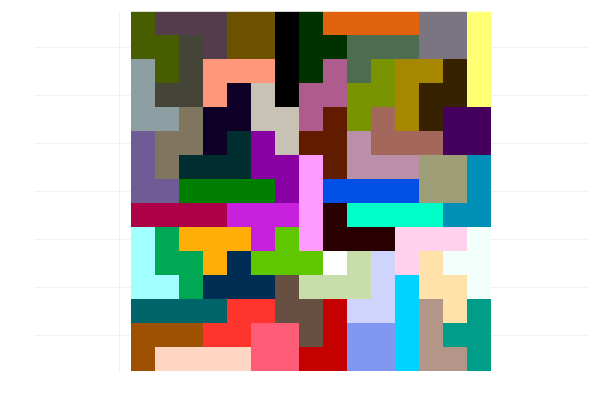


Tablero (letras por tipo, '.' vacío, '#' obstáculo):
Z L L L O O I T I I I I O O I 
Z Z L L O O I T T J J J O O I 
J Z L J J J I T S J S L L S I 
J L L J S Z I S S S S L S S I 
J J S S S Z Z S T S L L S O O 
J S S S J Z Z T T L L L L O O 
J S J J J Z Z I T L L L O O L 
J J I I I I Z I I I I I O O L 
I I I I T T T I L I I I I L L 
J Z T T T T T I L L L J J J T 
J Z Z T T T T T . J L J Z T T 
J J Z T T T Z J J J L I Z Z T 
I I I I Z Z Z Z L L L I J Z T 
J J J Z Z O O Z L O O I J T T 
J I I I I O O L L O O I J J T 


([50 26 … 13 2; 50 50 … 13 2; … ; 44 44 … 23 23; 44 11 … 40 23], Dict(5 => :I, 56 => :Z, 35 => :J, 55 => :Z, 30 => :L, 32 => :L, 6 => :I, 45 => :S, 4 => :I, 13 => :O…), Set{Tuple{Int64, Int64}}(), MathOptInterface.OPTIMAL)

In [42]:
board1, id_to_type1, blocked1, term1 = run_tetris_packing(H=15, W=15, p_block=0.0, seed=2026, time_limit=120.0)

Tablero: 15x15
Tipos de piezas: [:I, :O, :T, :L, :J, :S, :Z]
Obstáculos: 45 (20.0%)
Número total de colocaciones P: 1430

Estado solver: OPTIMAL
Número de piezas colocadas (obj): 43
Placements seleccionados: 43
Tetromino packing 15x15 — piezas=43 — bloqueadas=45


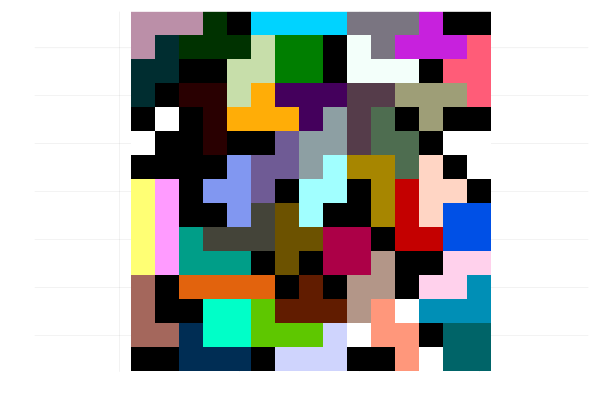


Tablero (letras por tipo, '.' vacío, '#' obstáculo):
J J J T # I I I I T T T T # # 
J S T T T S O O # L T T T T T 
S S # # S S O O # L L L # T T 
S # J J S T T T T L L T T T T 
# . # J T T T T S L Z # T # # 
. # I J # # S S S L Z Z # . . 
# # I # T S S S S J J Z T # . 
I I I T T S # S S # J J T T # 
I I I # T J T S # # J J T O O 
I I L J J J T T O O # J J O O 
I I L L L # T # O O S # # Z Z 
J # I I I I # T # S S # Z Z J 
J # # O O L T T T S Z . J J J 
J J L O O L L L J . Z Z # O O 
# # L L L # J J J # # Z . O O 


([32 32 … -1 -1; 32 35 … 19 16; … ; 31 31 … 10 10; -1 -1 … 10 10], Dict(5 => :I, 35 => :S, 30 => :J, 32 => :J, 6 => :O, 4 => :I, 13 => :T, 12 => :T, 28 => :J, 23 => :L…), Set([(12, 12), (11, 8), (8, 15), (15, 11), (1, 15), (10, 11), (7, 1), (11, 12), (6, 13), (12, 9)  …  (7, 4), (9, 9), (7, 14), (4, 2), (13, 2), (6, 6), (5, 3), (8, 10), (12, 2), (5, 14)]), MathOptInterface.OPTIMAL)

In [51]:
board2, id_to_type2, blocked2, term2 = run_tetris_packing(H=15, W=15, p_block=0.2, seed=2026, time_limit=120.0)